In [30]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

def versions():
    import scipy, sklearn, matplotlib
    return {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "sklearn": sklearn.__version__,
        "matplotlib": matplotlib.__version__,
    }

versions()

{'numpy': '1.21.5',
 'pandas': '1.4.4',
 'scipy': '1.9.1',
 'sklearn': '1.0.2',
 'matplotlib': '3.5.2'}

In [31]:
'''
Defining a regular expression to identify attribute headers
and 
identifying where each attribute by detecting whitespaces, numbers, dots, colons, etc
'''
ATTRIBUTE_HEADER = re.compile(r"^\s*(\d+)\.\s+([^:]+):\s*(.*)")

# Extracting the text into code
def extraction(text):
    return [
        part.split("=")[1]
        for part in text.replace(",", " ").split()      #Removing commas and spliting 
        if "=" in part
    ]

# Analyzing
def analyze_info_file(info_path: Path):
    attribute_names, attribute_values = [], {}
    current_attribute, buffer = None, ""
    '''
    attribute_names = list of names
    attribute_values = values of the listed names
    Using buffer for collecting text across multiple lines
    '''
    for line in info_path.read_text(encoding="utf-8").splitlines():
        line = line.rstrip()                             #Removing spaces for analyzing text
        match = ATTRIBUTE_HEADER.match(line)
        '''
        If a new attribute is found storing it into pervious attribute_names
        '''
        if match:
            if current_attribute:
                attribute_values[current_attribute] = extraction(buffer)

            current_attribute = match.group(2).strip()
            attribute_names.append(current_attribute)
            buffer = match.group(3)

        elif current_attribute and line.strip():
            buffer += " " + line.strip()

    if current_attribute:
        attribute_values[current_attribute] = extraction(buffer)

    return attribute_names, attribute_values


In [32]:
# Defining the function for both the text files
def mushroom_data(data_path: Path, info_path: Path = None):
    analyzed_names = []
    analyzed_attribute_values = {}

    # Analyzing attribute names and values from info file
    if info_path and info_path.exists():
        analyzed_names, analyzed_attribute_values = analyze_info_file(info_path)
    
    #Constructing the column names list
    attribute_names = analyzed_names
    col_names = ['class'] + attribute_names
    
    #Loading the dataset into a DataFrame
    df = pd.read_csv(
        data_path,
        header = None,
        names = col_names,
        na_values = '?',
        keep_default_na = True
    )

    return df, attribute_names, analyzed_attribute_values


In [33]:
# Loading the files
DATA_PATH = Path("C:/Users/Rajshree khajekar/Desktop/Study Material/Data Science Research Methods Autumn/Report DISCUS/mushroom/mushroom/agaricus-lepiota-data.txt")
INFO_PATH = Path("C:/Users/Rajshree khajekar/Desktop/Study Material/Data Science Research Methods Autumn/Report DISCUS/mushroom/mushroom/agaricus-lepiota-info.txt")

df, attribute_names, attribute_values = mushroom_data(DATA_PATH, INFO_PATH)

In [34]:
# Exploratory Data Analysis
def eda_summary(df):
    print("Exploratory Data Analysis ")
    print(f"Dataset Shape: {df.shape}")
    
    print("\nTARGET VARIABLE DISTRIBUTION")
    class_counts = df['class'].value_counts()
    class_pct = df['class'].value_counts(normalize=True) * 100
    print(f"Edible (e): {class_counts['e']:,} samples ({class_pct['e']:.1f}%)")
    print(f"Poisonous (p):  {class_counts['p']:,} samples ({class_pct['p']:.1f}%)")
    
eda_summary(df)

Exploratory Data Analysis 
Dataset Shape: (8124, 23)

TARGET VARIABLE DISTRIBUTION
Edible (e): 4,208 samples (51.8%)
Poisonous (p):  3,916 samples (48.2%)


In [35]:
'''
Doing more exploratory analysis
Measuring feature class cardinality i.e number of unique values
Counting missing values
Computing correlation with the target class
'''
def analyze_feature(df):
    feature_info = []

    for col in df.columns:
        if col != 'class':
            no_unique = df[col].nunique()
            missing = df[col].isnull().sum()

            feature_info.append({
                'Feature': col,
                'Unique': no_unique,
                'Missing': missing
            })

    feature_df = pd.DataFrame(feature_info)
    return feature_df

# Correlation
def correlation(df):
    df_encoded = df.apply(LabelEncoder().fit_transform)
    correlation_matrix = df_encoded.corr()
    return correlation_matrix

# Feature characteristics
feature_df = analyze_feature(df)
correlation_matrix = correlation(df)
correlation_df = (
    correlation_matrix['class']
    .drop('class')  # remove self-correlation
    .reset_index()
    .rename(columns={'index': 'Feature', 'class': 'Correlation with Class'})
)

# Merging 
combined_df = feature_df.merge(correlation_df, on = 'Feature', how = 'left')
combined_df = combined_df.sort_values(by = 'Correlation with Class', ascending = False)

print("COMBINED FEATURE ANALYSIS TABLE")
print(combined_df)

combined_df.to_excel(
    "combined_feature_analysis.xlsx",
    index=False
)


COMBINED FEATURE ANALYSIS TABLE
                     Feature  Unique  Missing  Correlation with Class
7                  gill-size       2        0                0.540024
20                population       6        0                0.298686
21                   habitat       7        0                0.217179
1                cap-surface       4        0                0.178446
19         spore-print-color       9        0                0.171961
10                stalk-root       4     2480                0.167975
16                veil-color       4        0                0.145142
5            gill-attachment       2        0                0.129200
0                  cap-shape       6        0                0.052951
2                  cap-color      10        0               -0.031384
4                       odor       9        0               -0.093552
9                stalk-shape       2        0               -0.102019
14    stalk-color-below-ring       9        0             

Chi-Square Parameters
                     Feature  Chi-Square Statistic        p-value
0                       odor           7659.726740   0.000000e+00
1          spore-print-color           4602.033170   0.000000e+00
2                 gill-color           3765.714086   0.000000e+00
3                  ring-type           2956.619278   0.000000e+00
4   stalk-surface-above-ring           2808.286287   0.000000e+00
5   stalk-surface-below-ring           2684.474076   0.000000e+00
6                  gill-size           2366.834257   0.000000e+00
7     stalk-color-above-ring           2237.898496   0.000000e+00
8     stalk-color-below-ring           2152.390891   0.000000e+00
9                   bruises?           2041.415647   0.000000e+00
10                population           1929.740891   0.000000e+00
11                   habitat           1573.777261   0.000000e+00
12              gill-spacing            984.143333  5.022978e-216
13                stalk-root            638.263763  5.

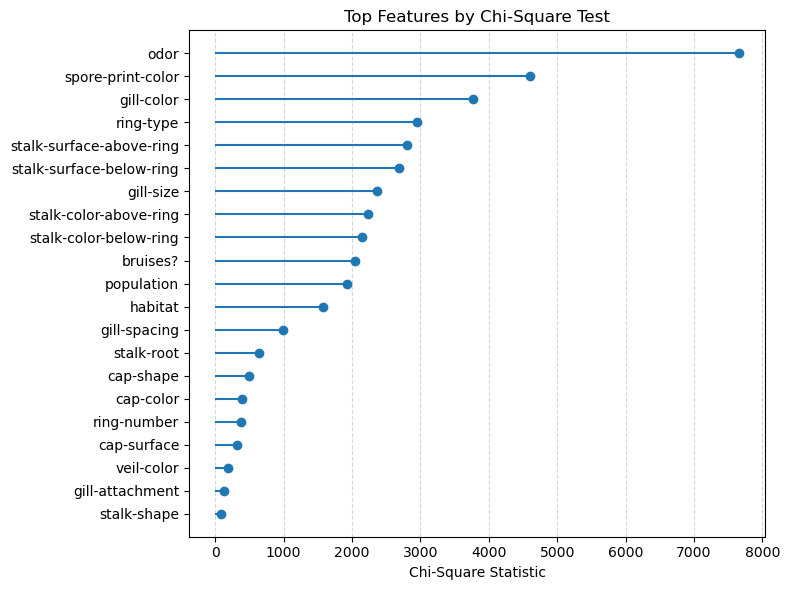

In [36]:
# Performing Chi-Square test
def chi_test(df):
    # Removing the veil-type from the class list 
    X = df.drop(columns=['class', 'veil-type'], errors='ignore')

    results = []

    # Chi-square test
    for feature in X.columns:
        contingency_table = pd.crosstab(df[feature], df['class'])
        chi, p_value, dof, expected = chi2_contingency(contingency_table)

        results.append({
            'Feature': feature,
            'Chi-Square Statistic': chi,
            'p-value': p_value
        })

    # Creating the table
    chi_square_df = (
        pd.DataFrame(results)
        .sort_values(by='Chi-Square Statistic', ascending=False)
        .reset_index(drop=True)
    )

    return chi_square_df

print('Chi-Square Parameters')
chi_data = chi_test(df)
print(chi_data)

chi_data.to_excel(
    "chi_square_results.xlsx",
    index=False
)

# Ploting
def chi_plot(chi_square_df, top_n=30):
    df = chi_square_df.head(top_n).sort_values('Chi-Square Statistic')

    plt.figure(figsize=(8, 6))
    plt.hlines(y=df['Feature'], xmin=0, xmax=df['Chi-Square Statistic'])
    plt.plot(df['Chi-Square Statistic'], df['Feature'], 'o')
    plt.xlabel('Chi-Square Statistic')
    plt.title('Top Features by Chi-Square Test')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


chi_plot(chi_data)


In [37]:
# Creating the rulebook 
def rules_tree(
    df, attribute_names,
    max_depth = 5,
    min_samples_leaf = 5,
    target_col='class'
):
    X = (
        df[attribute_names]
        .drop(columns=['veil-type'], errors='ignore')        # Ignoring the veil-type 
        .astype(str)
        .fillna('unknown')
    )

    y = df[target_col].astype(str).str.lower().map({
        'e': 'Edible', 'p': 'Poisonous'
    })

    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_enc = enc.fit_transform(X)

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    ).fit(X_enc, y)

    tree = clf.tree_

    parent = [-1] * tree.node_count
    for i in range(tree.node_count):
        for child in (tree.children_left[i], tree.children_right[i]):
            if child != -1:
                parent[child] = i

    def node_path(leaf):
        path = []
        while parent[leaf] != -1:
            p = parent[leaf]
            path.append((p, leaf == tree.children_left[p]))
            leaf = p
        return reversed(path)

    rules = []
    leaf_ids = clf.apply(X_enc)

    for leaf in np.unique(leaf_ids):
        idxs = np.where(leaf_ids == leaf)[0]
        counts = y.iloc[idxs].value_counts()
        pred = counts.idxmax()

        conditions = {}
        for p, went_left in node_path(leaf):
            feat = tree.feature[p]
            if feat < 0:
                continue

            cats = list(enc.categories_[feat])
            thr = int(np.floor(tree.threshold[p]))
            allowed = cats[:thr+1] if went_left else cats[thr+1:]

            fname = X.columns[feat]
            conditions[fname] = (
                list(set(conditions[fname]) & set(allowed))
                if fname in conditions else allowed
            )

        rules.append({
            "id": f"R{len(rules) + 1}",
            "support": len(idxs),
            "outcome": pred,
            "confidence": round(counts[pred] / len(idxs), 4),
            "conditions": conditions
        })

    return rules


In [38]:
def rulebook_table(rules):
    all_features = sorted({
        feat for r in rules for feat in r["conditions"].keys()
    })

    rows = []
    for r in rules:
        row = {"Rule ID": r["id"]}

        # Feature condition columns first
        for feat in all_features:
            values = r["conditions"].get(feat)
            row[feat] = ", ".join(values) if values else ""

        # Outcome-related columns LAST
        row["Outcome"] = r["outcome"]
        row["Confidence"] = r["confidence"]
        row["Support"] = r["support"]

        rows.append(row)

    return pd.DataFrame(rows)

rules = rules_tree(df, attribute_names)
rulebook_df = rulebook_table(rules)
print(rulebook_df)

rulebook_df.to_excel(
    "mushroom_rulebook.xlsx",
    index=False
)


   Rule ID                  cap-color cap-surface              gill-color  \
0       R1                                                     b, e, g, h   
1       R2                                                     b, e, g, h   
2       R3                                                     b, e, g, h   
3       R4                                                     b, e, g, h   
4       R5                                                     b, e, g, h   
5       R6                                   f, g              b, e, g, h   
6       R7                                   s, y              b, e, g, h   
7       R8                                         k, n, o, p, r, u, w, y   
8       R9                                         k, n, o, p, r, u, w, y   
9      R10                                         k, n, o, p, r, u, w, y   
10     R11                          b              k, n, o, p, r, u, w, y   
11     R12  c, e, g, n, p, r, u, w, y              k, n, o, p, r, u, w, y   